# Implementação do **stack ensemble** 

A ideia e usar um **meta-modelo** (Regressao Logistica) que aprende a combinar as probabilidades dos 5 modelos base (SVM, KNN, Extra Trees, Regressao Logistica, LightGBM) para fazer a previsao final.

### Como funciona:

Para cada `Janela Incremental` e cada `Temporada`, o meta-modelo aprende **progressivamente** dentro da propria temporada, imitando a janela incremental:

- **Janela = 5**: treina com as linhas 1 a 5, prediz a 6°. Depois treina com 1 a 6, prediz a 7°. E assim por diante.
- **Janela = 10**: treina com as linhas 1 a 10, prediz a 11°. 
- **Janela = 15**: treina com as linhas 1 a 15, prediz a 16°.

Imagem para facilitar 
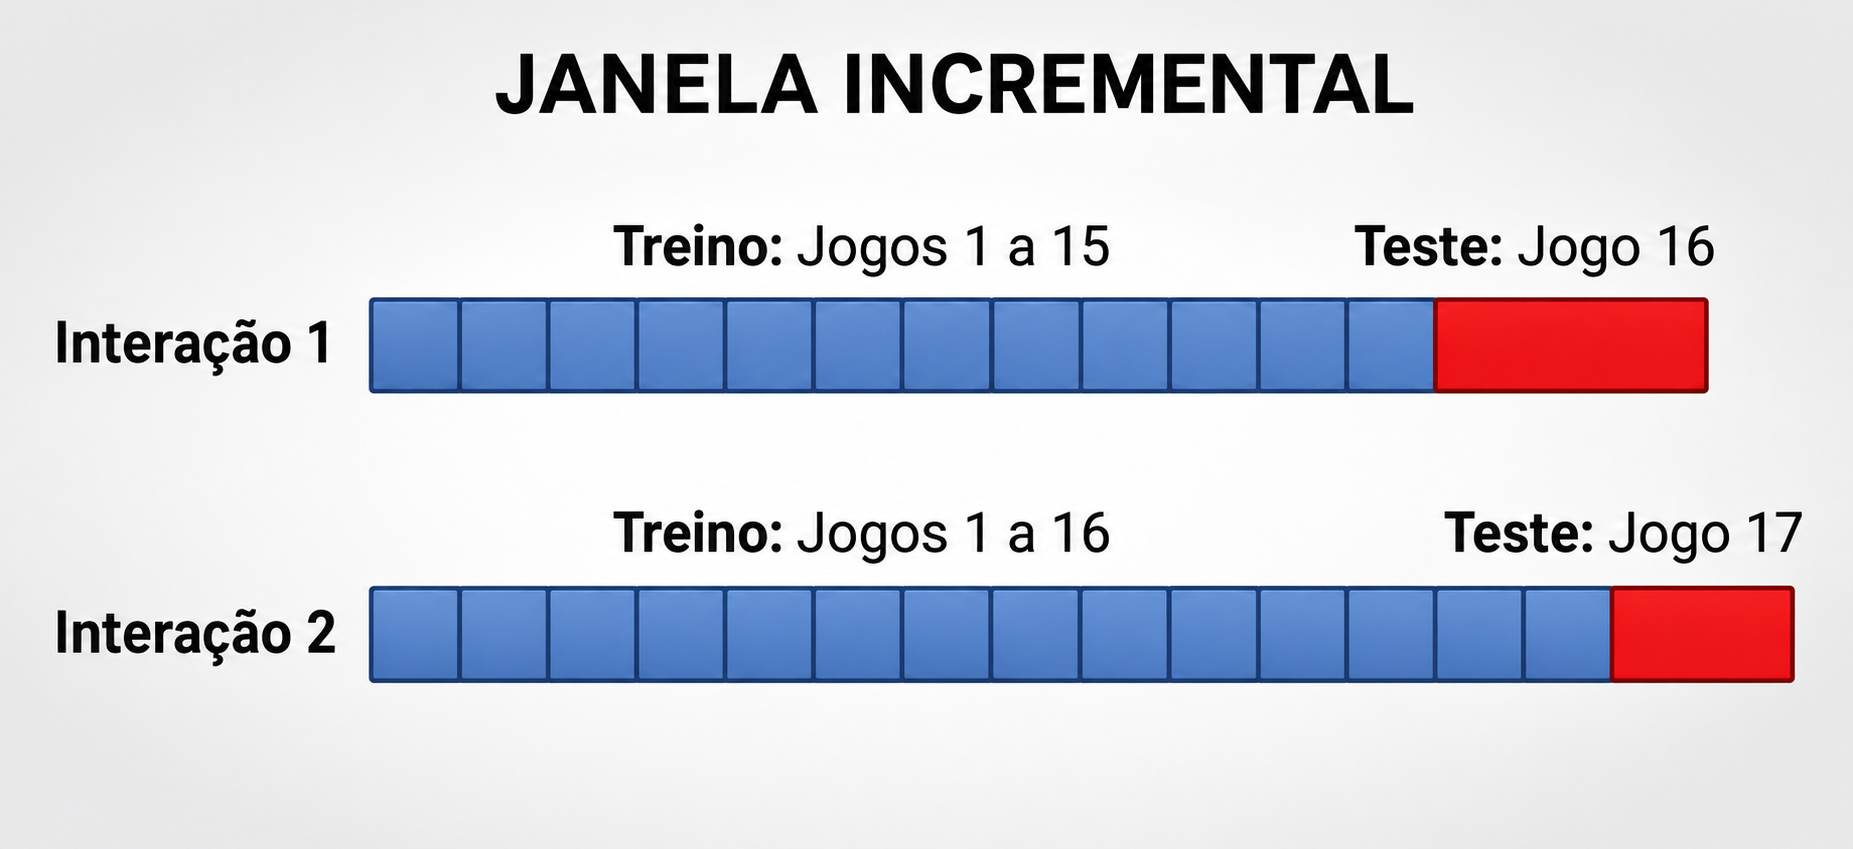

### Features do meta-modelo:
As 5 probabilidades dos modelos base: `prob_svm`, `prob_knn`, `prob_extra_trees`, `prob_regressao_logistica`, `prob_lightgbm`

### Target:
`Resultado Real` (0 ou 1)





## Importar bibliotecas

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## Configuração

- `META_DATASET_PATH`: caminho do meta-dataset gerado anteriormente com as probabilidades dos 5 modelos
- `SAIDA_STACK`: pasta onde salvarei os resultados do stack ensemble
- `SAIDA_EXP03`: pasta dos resultados do experimento 03 (para comparacao nos graficos)
- `FEATURES`: as 5 colunas de probabilidade que o meta-modelo usa como entrada
- `TARGET`: a coluna alvo

In [2]:
META_DATASET_PATH = os.path.abspath(
    os.path.join('..', 'results', 'experimento_04_stack', 'meta_dataset_stack.csv')
)
SAIDA_STACK = os.path.abspath(
    os.path.join('..', 'results', 'experimento_04_stack')
)
SAIDA_EXP03 = os.path.abspath(
    os.path.join('..', 'results', 'experimento_03')
)

FEATURES = [
    'prob_svm',
    'prob_knn',
    'prob_extra_trees',
    'prob_regressao_logistica',
    'prob_lightgbm',
]

TARGET = 'Resultado Real'

JANELAS = [5, 10, 15]

print(f'Meta-dataset: {META_DATASET_PATH}')
print(f'Saida: {SAIDA_STACK}')
print(f'Features: {FEATURES}')
print(f'Target: {TARGET}')

Meta-dataset: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_04_stack\meta_dataset_stack.csv
Saida: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_04_stack
Features: ['prob_svm', 'prob_knn', 'prob_extra_trees', 'prob_regressao_logistica', 'prob_lightgbm']
Target: Resultado Real


## Carregar o meta-dataset

Carreguei o meta-dataset que foi gerado anteriormente pelo notebook `meta-dataset.ipynb`. Cada linha representa um jogo, com as probabilidades previstas pelos 5 modelos base e o resultado real.

In [3]:
df_meta = pd.read_csv(META_DATASET_PATH)

print(f'Shape: {df_meta.shape}')
print(f'Janelas: {sorted(df_meta["Janela Incremental"].unique())}')
print(f'Temporadas: {sorted(df_meta["Temporada"].unique())}')
df_meta.head()

Shape: (10740, 9)
Janelas: [np.int64(5), np.int64(10), np.int64(15)]
Temporadas: ['2008-2009', '2009-2010', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024']


,Janela Incremental,Temporada,Ordem Jogo Temporada,Resultado Real,prob_svm,prob_knn,prob_extra_trees,prob_regressao_logistica,prob_lightgbm
0,5,2008-2009,1,1,0.733335,0.666667,0.800000,0.799964,0.800000
1,5,2008-2009,2,0,0.769852,0.666667,0.833333,0.833331,0.833333
2,5,2008-2009,3,0,0.238587,0.333333,0.097143,0.535707,0.600000
3,5,2008-2009,4,1,0.190341,0.000000,0.097143,0.405470,0.545455
4,5,2008-2009,5,1,0.561735,0.333333,0.574286,0.551301,0.583333


## Distribuição do Resultado Real

Antes de treinar o stack ensemble, conferi a proporcao das classes em cada janela, só para ter uma noção. Como o `Resultado Real` e binario (`0` ou `1`), a media dessa coluna representa diretamente o percentual de jogos com classe `1`.

In [12]:
distribuicao_classes = (
    df_meta
    .groupby('Janela Incremental')
    .agg(
        Total=('Resultado Real', 'count'),
        Classe_1=('Resultado Real', 'sum'),
        Percentual_Classe_1=('Resultado Real', 'mean'),
    )
    .reset_index()
)

distribuicao_classes['Classe_0'] = (
    distribuicao_classes['Total'] - distribuicao_classes['Classe_1']
)

distribuicao_classes = distribuicao_classes[
    ['Janela Incremental', 'Total', 'Classe_0', 'Classe_1', 'Percentual_Classe_1']
]

distribuicao_classes['Percentual_Classe_1'] = (
    distribuicao_classes['Percentual_Classe_1'].round(4)
)

distribuicao_classes


,Janela Incremental,Total,Classe_0,Classe_1,Percentual_Classe_1
0,5,3650,1500,2150,0.5890
1,10,3580,1469,2111,0.5897
2,15,3510,1431,2079,0.5923


##  Stack Ensemble com Janela Incremental


1. Para cada `Janela Incremental` e cada `Temporada`, filtrei os dados e ordenei pela `Ordem Jogo Temporada`
2. Comecei treinando com as primeiras `janela` linhas e prevendo a proxima
3. A cada iteração, expandi o conjunto de treino com mais uma linha e previ a seguinte e assim por diante, vou colocar uma imagem para ficar mais facil o entendimento
4. Usei **Regressao Logistica** como meta-learner
5. Armazenei cada previsao para calcular as metricas depois



## $$$ATENÇÃO AQUI PROFESSOR!!!!!!!$$$
em algumas temporadas, os primeiros jogos da janela podem ter apenas uma classe no `Resultado Real` (por exemplo, so vitoria). Nesses casos, a Regressao Logistica nao consegue treinar, exemplo: 
Jogo 1: probs dos 5 modelos -> Resultado Real = 1
Jogo 2: probs dos 5 modelos -> Resultado Real = 1
Jogo 3: probs dos 5 modelos -> Resultado Real = 1
Jogo 4: probs dos 5 modelos -> Resultado Real = 1
Jogo 5: probs dos 5 modelos -> Resultado Real = 1

veja professor que mesmo que as probabilidades sejam diferentes entre si, o alvo verdadeiro só tem uma classe: 1

pq a regressão logística é um classificador que aprende uma fronteira entre classes. Para ela aprender essa fronteira, ela precisa ter exemplos de pelo menos duas classes:

alguns jogos com Resultado Real = 1
alguns jogos com Resultado Real = 0

Se os 5 primeiros jogos forem todos 1, ela não tem nenhum exemplo da classe 0, faz sentido isso?? 

In [11]:
todas_predicoes = []
resultados_resumo = []

for janela in JANELAS:
    df_janela = df_meta[df_meta['Janela Incremental'] == janela].copy()
    temporadas = sorted(df_janela['Temporada'].unique())

    for temporada in temporadas:
        df_temp = df_janela[df_janela['Temporada'] == temporada].copy()
        df_temp = df_temp.sort_values('Ordem Jogo Temporada').reset_index(drop=True)

        n_jogos = len(df_temp)

        if n_jogos <= janela:
            print(
                f'[AVISO] Janela={janela} | {temporada} | '
                f'Apenas {n_jogos} jogos, insuficiente para treinar e prever. Pulando.'
            )
            continue

        y_true_temp = []
        y_pred_temp = []
        y_prob_temp = []

        for i in range(janela, n_jogos):
            X_train = df_temp.loc[:i-1, FEATURES]
            y_train = df_temp.loc[:i-1, TARGET]

            X_test = df_temp.loc[[i], FEATURES]
            y_test = df_temp.loc[i, TARGET]

            if y_train.nunique() < 2:
                classe_unica = int(y_train.iloc[0])
                pred = classe_unica
                prob_classe_1 = 1.0 if classe_unica == 1 else 0.0
            else:
                meta_model = LogisticRegression(
                    max_iter=1000,
                    solver='lbfgs',
                    random_state=42
                )
                meta_model.fit(X_train, y_train)

                pred = meta_model.predict(X_test)[0]
                prob = meta_model.predict_proba(X_test)[0]
                prob_classe_1 = float(prob[1]) if len(prob) > 1 else float(prob[0])

            y_true_temp.append(int(y_test))
            y_pred_temp.append(int(pred))
            y_prob_temp.append(prob_classe_1)

            todas_predicoes.append({
                'Janela Incremental': janela,
                'Temporada': temporada,
                'Ordem Jogo Temporada': int(df_temp.loc[i, 'Ordem Jogo Temporada']),
                'Resultado Real': int(y_test),
                'Previsao': int(pred),
                'Probabilidade Classe 1': prob_classe_1,
            })

        if len(y_true_temp) > 0:
            acc = accuracy_score(y_true_temp, y_pred_temp)
            f1 = f1_score(y_true_temp, y_pred_temp, average='weighted', zero_division=0)

            resultados_resumo.append({
                'Janela Incremental': janela,
                'Temporada': temporada,
                'Jogos Avaliados': len(y_true_temp),
                'Acur\u00e1cia': round(acc, 4),
                'F1-Score': round(f1, 4),
            })

            print(
                f'Janela={janela} | {temporada} | '
                f'Jogos: {len(y_true_temp)} | '
                f'Acuracia: {acc:.4f} | '
                f'F1: {f1:.4f}'
            )

print(f'\nTotal de predicoes: {len(todas_predicoes)}')

Janela=5 | 2008-2009 | Jogos: 226 | Acuracia: 0.6549 | F1: 0.6280
Janela=5 | 2009-2010 | Jogos: 151 | Acuracia: 0.6755 | F1: 0.5622
Janela=5 | 2011-2012 | Jogos: 165 | Acuracia: 0.6788 | F1: 0.5984
Janela=5 | 2012-2013 | Jogos: 339 | Acuracia: 0.6460 | F1: 0.6001
Janela=5 | 2013-2014 | Jogos: 305 | Acuracia: 0.5967 | F1: 0.5529
Janela=5 | 2014-2015 | Jogos: 274 | Acuracia: 0.6314 | F1: 0.5764
Janela=5 | 2015-2016 | Jogos: 244 | Acuracia: 0.5820 | F1: 0.5785
Janela=5 | 2016-2017 | Jogos: 249 | Acuracia: 0.5301 | F1: 0.4775
Janela=5 | 2018-2019 | Jogos: 207 | Acuracia: 0.6135 | F1: 0.5835
Janela=5 | 2019-2020 | Jogos: 196 | Acuracia: 0.5408 | F1: 0.5313
Janela=5 | 2020-2021 | Jogos: 255 | Acuracia: 0.6431 | F1: 0.6253
Janela=5 | 2021-2022 | Jogos: 293 | Acuracia: 0.6416 | F1: 0.6097
Janela=5 | 2022-2023 | Jogos: 301 | Acuracia: 0.5947 | F1: 0.5864
Janela=5 | 2023-2024 | Jogos: 375 | Acuracia: 0.6427 | F1: 0.6338
Janela=10 | 2008-2009 | Jogos: 216 | Acuracia: 0.6991 | F1: 0.6732
Janela=10

## Salvar resultados

Salvei dois CSVs:
- **Predicoes detalhadas**: cada linha e uma previsao do stack ensemble com a probabilidade
- **Resumo por temporada**: acuracia e F1-Score agregados por janela e temporada

In [5]:
os.makedirs(SAIDA_STACK, exist_ok=True)

df_predicoes = pd.DataFrame(todas_predicoes)
predicoes_path = os.path.join(SAIDA_STACK, 'stack_ensemble_predicoes.csv')
df_predicoes.to_csv(predicoes_path, index=False)
print(f'Predicoes salvas em: {predicoes_path}')
print(f'Shape: {df_predicoes.shape}')

df_resumo = pd.DataFrame(resultados_resumo)
resumo_path = os.path.join(SAIDA_STACK, 'stack_ensemble_resumo.csv')
df_resumo.to_csv(resumo_path, index=False)
print(f'\nResumo salvo em: {resumo_path}')
print(df_resumo.to_string(index=False))

Predicoes salvas em: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_04_stack\stack_ensemble_predicoes.csv
Shape: (10320, 6)

Resumo salvo em: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_04_stack\stack_ensemble_resumo.csv
 Janela Incremental Temporada  Jogos Avaliados  Acurácia  F1-Score
                  5 2008-2009              226    0.6549    0.6280
                  5 2009-2010              151    0.6755    0.5622
                  5 2011-2012              165    0.6788    0.5984
                  5 2012-2013              339    0.6460    0.6001
                  5 2013-2014              305    0.5967    0.5529
                  5 2014-2015              274    0.6314    0.5764
                  5 2015-2016              244    0.5820    0.5785
                  5 2016-2017              249    0.5301    0.4775
                  5 2018-2019              207    0.6135    0.5835
                  5 2019-2020             



funcao `plot_comparativo(janela)` que gera um grafico comparando o stack ensemble com:
- Os 5 modelos individuais
- O voto majoritario
- O soft voting

Assim consigo visualizar se o stacking realmente melhora os resultados em relacao as abordagens mais simples.

In [7]:
def plot_comparativo(janela):
    modelos = {
        'SVM':                'svm',
        'KNN':                'knn',
        'Extra Trees':        'extra_trees',
        'Regressao Logistica':'regressao_logistica',
        'LightGBM':           'lightgbm',
    }

    jogos_por_temporada = {
        '2008-2009': 237, '2009-2010': 162, '2011-2012': 176,
        '2012-2013': 350, '2013-2014': 316, '2014-2015': 285,
        '2015-2016': 255, '2016-2017': 260, '2018-2019': 218,
        '2019-2020': 207, '2020-2021': 266, '2021-2022': 304,
        '2022-2023': 312, '2023-2024': 386
    }

    cores = {
        'SVM':                '#1f77b4',
        'KNN':                '#ff7f0e',
        'Extra Trees':        '#2ca02c',
        'Regressao Logistica':'#d62728',
        'LightGBM':           '#9467bd',
    }

    marcadores = {
        'SVM':                'o',
        'KNN':                's',
        'Extra Trees':        '^',
        'Regressao Logistica':'D',
        'LightGBM':           'P',
    }

    temporadas_order = list(jogos_por_temporada.keys())

    dfs_plot = []
    for nome_modelo, arquivo_modelo in modelos.items():
        path = os.path.join(
            SAIDA_EXP03,
            f'{arquivo_modelo}_experimento_03_janela{janela}.csv'
        )
        if not os.path.exists(path):
            continue
        df_m = pd.read_csv(path)
        df_m['Modelo'] = nome_modelo
        dfs_plot.append(df_m)

    dados_plot = pd.concat(dfs_plot, ignore_index=True)
    dados_plot['Acur\u00e1cia'] = dados_plot['Acur\u00e1cia'].astype(float)
    dados_plot['Temporada'] = pd.Categorical(
        dados_plot['Temporada'], categories=temporadas_order, ordered=True
    )
    dados_plot = dados_plot.sort_values('Temporada')

    ensembles = {}

    voto_path = os.path.join(SAIDA_EXP03, 'ensemble_voto_majoritario.csv')
    if os.path.exists(voto_path):
        df_voto = pd.read_csv(voto_path)
        df_voto = df_voto[df_voto['Janela Incremental'] == janela].copy()
        df_voto['Acur\u00e1cia'] = df_voto['Acur\u00e1cia'].astype(float)
        df_voto['Temporada'] = pd.Categorical(
            df_voto['Temporada'], categories=temporadas_order, ordered=True
        )
        df_voto = df_voto.sort_values('Temporada')
        ensembles['Voto Majoritario'] = df_voto

    soft_path = os.path.join(SAIDA_EXP03, 'ensemble_soft_voting.csv')
    if os.path.exists(soft_path):
        df_soft = pd.read_csv(soft_path)
        df_soft = df_soft[df_soft['Janela Incremental'] == janela].copy()
        df_soft['Acur\u00e1cia'] = df_soft['Acur\u00e1cia'].astype(float)
        df_soft['Temporada'] = pd.Categorical(
            df_soft['Temporada'], categories=temporadas_order, ordered=True
        )
        df_soft = df_soft.sort_values('Temporada')
        ensembles['Soft Voting'] = df_soft

    df_stack = df_resumo[df_resumo['Janela Incremental'] == janela].copy()
    df_stack['Temporada'] = pd.Categorical(
        df_stack['Temporada'], categories=temporadas_order, ordered=True
    )
    df_stack = df_stack.sort_values('Temporada')

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(16, 9),
        gridspec_kw={'height_ratios': [3, 1]},
        sharex=True
    )

    for nome_modelo in modelos.keys():
        subset = dados_plot[dados_plot['Modelo'] == nome_modelo].sort_values('Temporada')
        ax1.plot(
            subset['Temporada'],
            subset['Acur\u00e1cia'],
            marker=marcadores[nome_modelo],
            color=cores[nome_modelo],
            linewidth=1.5,
            markersize=5,
            label=nome_modelo,
            alpha=0.5
        )

    if 'Voto Majoritario' in ensembles:
        df_e = ensembles['Voto Majoritario']
        ax1.plot(
            df_e['Temporada'], df_e['Acur\u00e1cia'],
            marker='x', color='gray', linewidth=2, markersize=8,
            linestyle=':', label='Voto Majoritario', alpha=0.7
        )

    if 'Soft Voting' in ensembles:
        df_e = ensembles['Soft Voting']
        ax1.plot(
            df_e['Temporada'], df_e['Acur\u00e1cia'],
            marker='+', color='dimgray', linewidth=2, markersize=8,
            linestyle='-.', label='Soft Voting', alpha=0.7
        )

    ax1.plot(
        df_stack['Temporada'],
        df_stack['Acur\u00e1cia'],
        marker='*',
        color='red',
        linewidth=3,
        markersize=12,
        linestyle='--',
        label='Stack Ensemble',
        zorder=10
    )

    ax1.set_title(
        f'Stack Ensemble vs Modelos | Janela = {janela}',
        fontsize=14
    )
    ax1.set_ylabel('Acuracia', fontsize=12)
    ax1.set_ylim(0.45, 0.90)
    ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
    ax1.legend(loc='upper right', fontsize=9, ncol=2)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.tick_params(axis='x', rotation=45)

    temporadas_presentes = [t for t in temporadas_order if t in jogos_por_temporada]
    jogos_vals = [jogos_por_temporada[t] for t in temporadas_presentes]

    ax2.bar(
        temporadas_presentes, jogos_vals,
        color='#1f77b4', alpha=0.4, edgecolor='#1f77b4'
    )
    for i, v in enumerate(jogos_vals):
        ax2.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=8)

    ax2.set_ylabel('Jogos', fontsize=10)
    ax2.set_ylim(0, max(jogos_vals) * 1.25)
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    print(f'\nJanela = {janela} \u2014 Resumo Stack Ensemble:')
    print(df_stack[['Temporada', 'Jogos Avaliados', 'Acur\u00e1cia', 'F1-Score']].to_string(index=False))
    print()

## stack Ensemble vs Todos

grafico comparativo para cada uma das 3 janelas incrementais (5, 10, 15) igual vinha fazendo

Cada grafico mostra:
- As 5 linhas dos modelos individuais (mais transparentes)
- A linha do voto majoritario (cinza, pontilhada)
- A linha do soft voting (cinza, traco-ponto)
- A linha **vermelha** do stack ensemble (destaque)

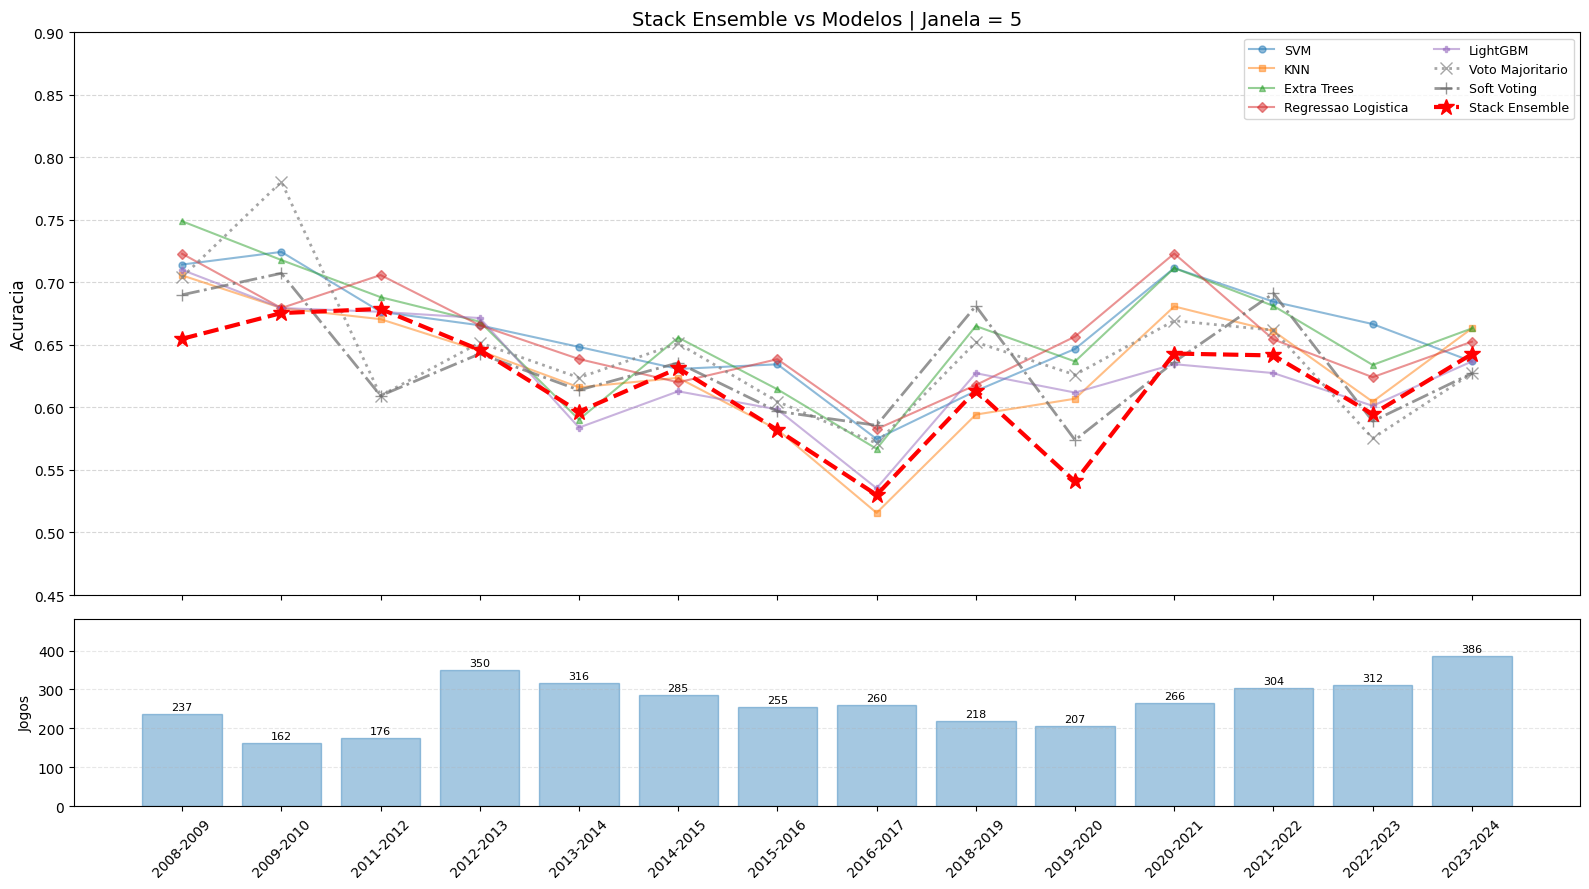


Janela = 5 — Resumo Stack Ensemble:
Temporada  Jogos Avaliados  Acurácia  F1-Score
2008-2009              226    0.6549    0.6280
2009-2010              151    0.6755    0.5622
2011-2012              165    0.6788    0.5984
2012-2013              339    0.6460    0.6001
2013-2014              305    0.5967    0.5529
2014-2015              274    0.6314    0.5764
2015-2016              244    0.5820    0.5785
2016-2017              249    0.5301    0.4775
2018-2019              207    0.6135    0.5835
2019-2020              196    0.5408    0.5313
2020-2021              255    0.6431    0.6253
2021-2022              293    0.6416    0.6097
2022-2023              301    0.5947    0.5864
2023-2024              375    0.6427    0.6338



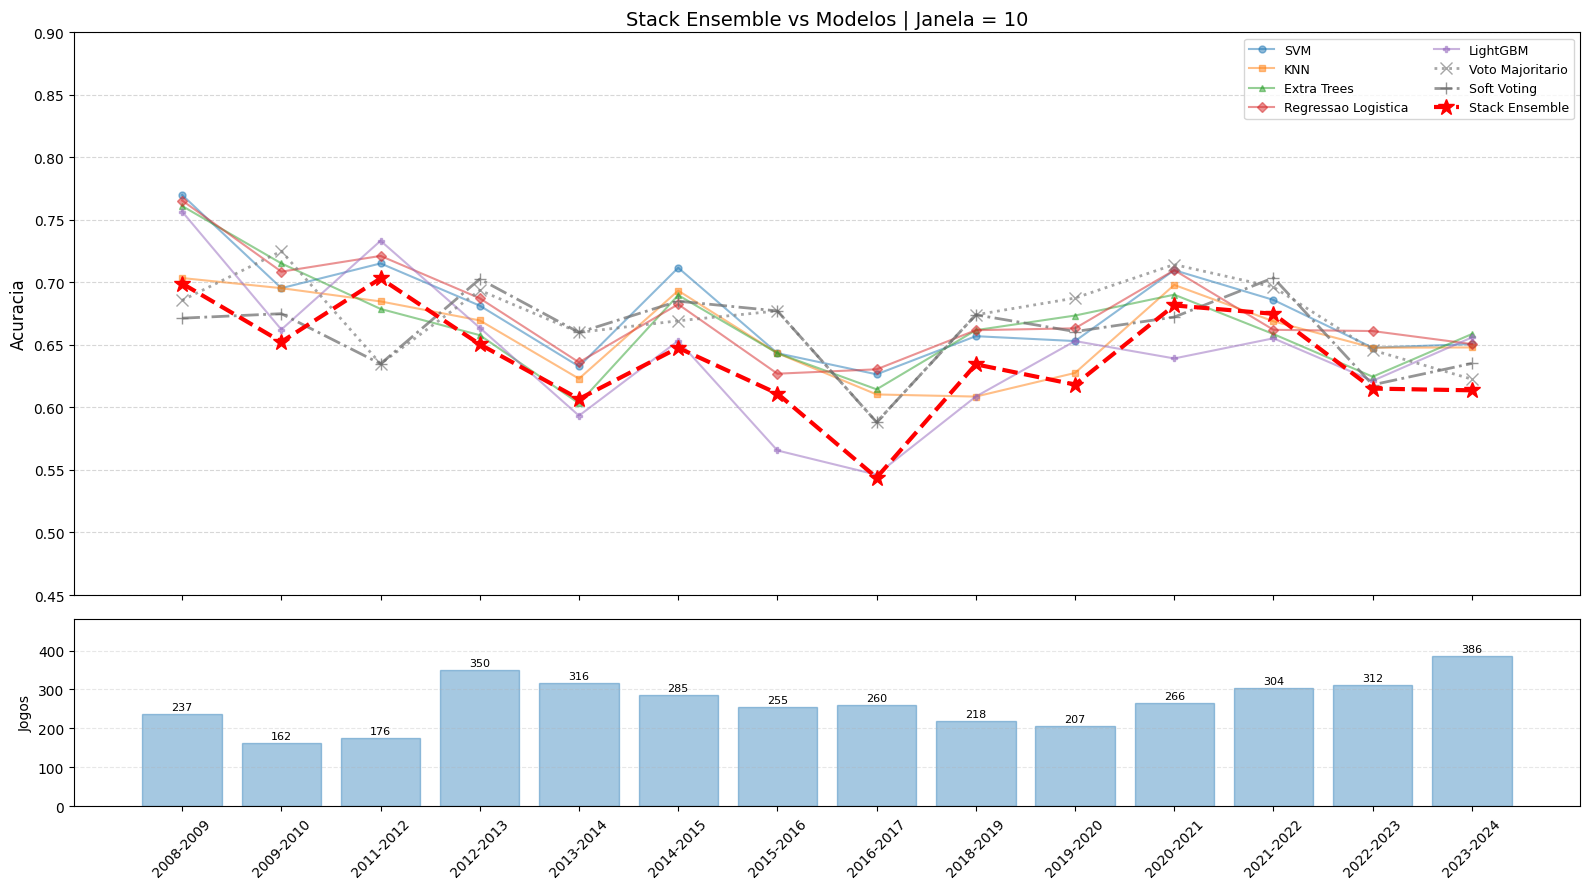


Janela = 10 — Resumo Stack Ensemble:
Temporada  Jogos Avaliados  Acurácia  F1-Score
2008-2009              216    0.6991    0.6732
2009-2010              141    0.6525    0.5723
2011-2012              155    0.7032    0.6619
2012-2013              329    0.6505    0.6088
2013-2014              295    0.6068    0.5834
2014-2015              264    0.6477    0.6247
2015-2016              234    0.6111    0.6052
2016-2017              239    0.5439    0.5128
2018-2019              197    0.6345    0.6182
2019-2020              186    0.6183    0.6139
2020-2021              245    0.6816    0.6675
2021-2022              283    0.6749    0.6313
2022-2023              291    0.6151    0.6095
2023-2024              365    0.6137    0.5993



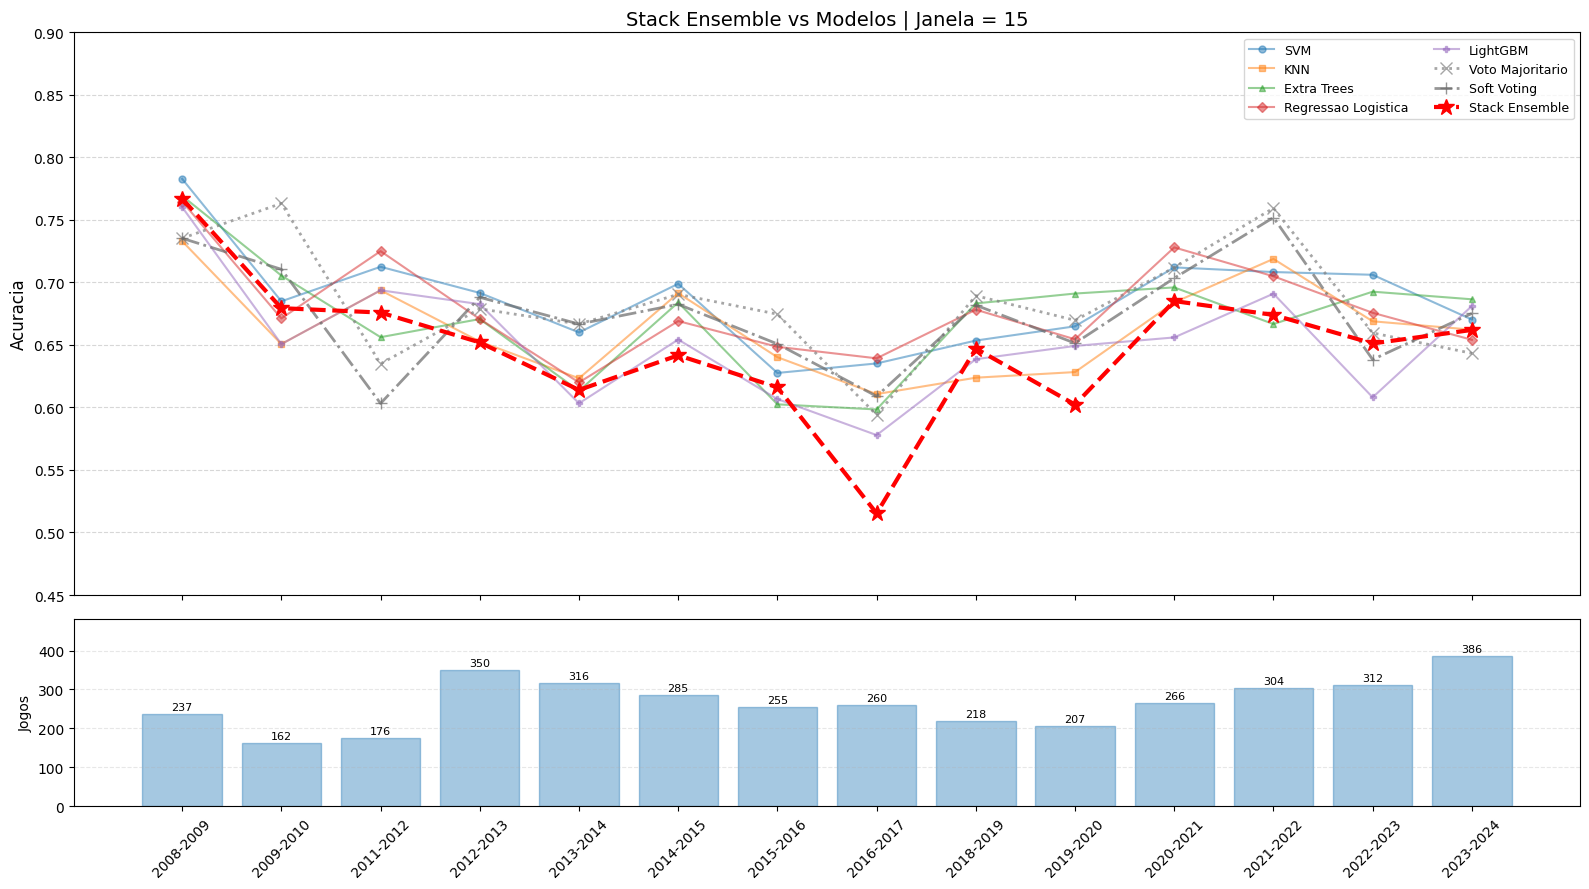


Janela = 15 — Resumo Stack Ensemble:
Temporada  Jogos Avaliados  Acurácia  F1-Score
2008-2009              206    0.7670    0.7511
2009-2010              131    0.6794    0.6135
2011-2012              145    0.6759    0.6108
2012-2013              319    0.6520    0.6151
2013-2014              285    0.6140    0.5766
2014-2015              254    0.6417    0.6247
2015-2016              224    0.6161    0.5796
2016-2017              229    0.5153    0.4929
2018-2019              187    0.6471    0.6134
2019-2020              176    0.6023    0.5979
2020-2021              235    0.6851    0.6717
2021-2022              273    0.6740    0.6470
2022-2023              281    0.6512    0.6430
2023-2024              355    0.6620    0.6435



In [8]:
for janela in JANELAS:
    plot_comparativo(janela)

## Resumo Comparativo Final

Aqui criei uma tabela final comparando a **media de acuracia** de cada abordagem (modelos individuais, voto majoritario, soft voting e stack ensemble) ao longo de todas as temporadas, para cada janela.

In [9]:
for janela in JANELAS:
    print(f'\n{"=" * 70}')
    print(f'JANELA = {janela}')
    print(f'{"=" * 70}')

    tabela_comparativa = []

    modelos_individuais = {
        'SVM': 'svm', 'KNN': 'knn', 'Extra Trees': 'extra_trees',
        'Regressao Logistica': 'regressao_logistica', 'LightGBM': 'lightgbm'
    }
    for nome, arquivo in modelos_individuais.items():
        path = os.path.join(
            SAIDA_EXP03,
            f'{arquivo}_experimento_03_janela{janela}.csv'
        )
        if os.path.exists(path):
            df_m = pd.read_csv(path)
            tabela_comparativa.append({
                'Modelo': nome,
                'Media Acuracia': round(df_m['Acur\u00e1cia'].astype(float).mean(), 4),
                'Desvio Padrao': round(df_m['Acur\u00e1cia'].astype(float).std(), 4),
            })

    voto_path = os.path.join(SAIDA_EXP03, 'ensemble_voto_majoritario.csv')
    if os.path.exists(voto_path):
        df_v = pd.read_csv(voto_path)
        df_v = df_v[df_v['Janela Incremental'] == janela]
        tabela_comparativa.append({
            'Modelo': 'Voto Majoritario',
            'Media Acuracia': round(df_v['Acur\u00e1cia'].astype(float).mean(), 4),
            'Desvio Padrao': round(df_v['Acur\u00e1cia'].astype(float).std(), 4),
        })

    soft_path = os.path.join(SAIDA_EXP03, 'ensemble_soft_voting.csv')
    if os.path.exists(soft_path):
        df_s = pd.read_csv(soft_path)
        df_s = df_s[df_s['Janela Incremental'] == janela]
        tabela_comparativa.append({
            'Modelo': 'Soft Voting',
            'Media Acuracia': round(df_s['Acur\u00e1cia'].astype(float).mean(), 4),
            'Desvio Padrao': round(df_s['Acur\u00e1cia'].astype(float).std(), 4),
        })

    df_st = df_resumo[df_resumo['Janela Incremental'] == janela]
    tabela_comparativa.append({
        'Modelo': '>>> Stack Ensemble <<<',
        'Media Acuracia': round(df_st['Acur\u00e1cia'].astype(float).mean(), 4),
        'Desvio Padrao': round(df_st['Acur\u00e1cia'].astype(float).std(), 4),
    })

    df_comp = pd.DataFrame(tabela_comparativa)
    df_comp = df_comp.sort_values('Media Acuracia', ascending=False)
    print(df_comp.to_string(index=False))


JANELA = 5
                Modelo  Media Acuracia  Desvio Padrao
           Extra Trees          0.6602         0.0497
                   SVM          0.6592         0.0416
   Regressao Logistica          0.6559         0.0410
      Voto Majoritario          0.6435         0.0534
           Soft Voting          0.6344         0.0434
                   KNN          0.6321         0.0501
              LightGBM          0.6291         0.0450
>>> Stack Ensemble <<<          0.6194         0.0457

JANELA = 10
                Modelo  Media Acuracia  Desvio Padrao
                   SVM          0.6772         0.0402
   Regressao Logistica          0.6763         0.0391
      Voto Majoritario          0.6696         0.0369
           Extra Trees          0.6665         0.0410
           Soft Voting          0.6613         0.0322
                   KNN          0.6587         0.0335
              LightGBM          0.6434         0.0568
>>> Stack Ensemble <<<          0.6395         0.0427

JA

## Previsoes vs Realidade

só para entender onde o modelo está erradno comparei a distribuicao das **previsoes** com a distribuicao dos **resultados reais**.

Se o modelo preve muito mais classe 1 do que o real, ele esta com vies para vitoria. Se preve menos, esta conservador demais.

In [10]:
print('DISTRIBUICAO DAS PREVISOES vs REALIDADE')
print('=' * 80)

for janela in JANELAS:
    df_j = df_predicoes[df_predicoes['Janela Incremental'] == janela]
    total = len(df_j)

    prev_1 = int((df_j['Previsao'] == 1).sum())
    prev_0 = int((df_j['Previsao'] == 0).sum())

    real_1 = int((df_j['Resultado Real'] == 1).sum())
    real_0 = int((df_j['Resultado Real'] == 0).sum())

    print(f'\nJanela={janela:>2}')
    print(f'  Previsoes:  total={total} | classe_1={prev_1} | classe_0={prev_0} | {prev_1}/{total} = {prev_1/total:.4f}')
    print(f'  Realidade:  total={total} | classe_1={real_1} | classe_0={real_0} | {real_1}/{total} = {real_1/total:.4f}')
    print(f'  Diferenca:  o modelo preve {abs(prev_1 - real_1)} jogos {"a mais" if prev_1 > real_1 else "a menos"} como classe 1')


DISTRIBUICAO DAS PREVISOES vs REALIDADE

Janela= 5
  Previsoes:  total=3580 | classe_1=2695 | classe_0=885 | 2695/3580 = 0.7528
  Realidade:  total=3580 | classe_1=2110 | classe_0=1470 | 2110/3580 = 0.5894
  Diferenca:  o modelo preve 585 jogos a mais como classe 1

Janela=10
  Previsoes:  total=3440 | classe_1=2531 | classe_0=909 | 2531/3440 = 0.7358
  Realidade:  total=3440 | classe_1=2039 | classe_0=1401 | 2039/3440 = 0.5927
  Diferenca:  o modelo preve 492 jogos a mais como classe 1

Janela=15
  Previsoes:  total=3300 | classe_1=2472 | classe_0=828 | 2472/3300 = 0.7491
  Realidade:  total=3300 | classe_1=1955 | classe_0=1345 | 1955/3300 = 0.5924
  Diferenca:  o modelo preve 517 jogos a mais como classe 1
